# Pre-class notebook — a list of matminer features

**MS697 AI-driven Materials Development**
`Lecture 3 — Features (compositional and structural fingerprints) for materials`

A walk through the featurizers available in `matminer`, kind by kind. The table at the top
lists 17 composition, 20 structure and 9 site featurizers with their dimension, what they
compute, and whether anything has to be prepared first. The parts that follow apply those
featurizers to a single material, TiO₂, one at a time, and look at the actual values and
dimensions. Featurizers that need oxidation states, that need `fit` to be called first, or
that need a Materials Project key are marked as such. Because every example uses the same
material, it is easy to compare how one crystal turns into a different vector under each
featurizer. Only the last part, Part 6, uses 100 materials, in order to see with two
correlation matrices how far the Magpie element-property features move together with
the composition, structure and site features.

## The full list

Every featurizer this notebook goes through. A `dim` of `—` means the dimension
depends on the arguments or on the result of `fit`. The `needs` column says what has
to be prepared before featurizing: `oxid. states` means the input has to go through
`CompositionToOxidComposition` / `StructureToOxidStructure` first, `fit` means `fit()`
has to be called first, `preset` means the site featurizer has to be chosen, `nn` means a neighbour-finding
class from `pymatgen.analysis.local_env` has to be passed in, and `MP key` means a
Materials Project API key is required.

### Composition features (17)

| featurizer | dim | what it computes | needs |
|---|---|---|---|
| `ElementFraction` | 118 | atomic fraction per element | — |
| `ElementProperty (magpie)` | 132 | 22 elem. props x 6 stats | — |
| `Stoichiometry` | 6 | Lp norms of atomic fractions | — |
| `ValenceOrbital` | 8 | s/p/d/f valence electrons | — |
| `IonProperty` | 3 | electronegativity diff., ionicity | — |
| `BandCenter` | 1 | geometric mean of electronegativity | — |
| `AtomicOrbitals` | 10 | HOMO/LUMO of constituent elements | — |
| `AtomicPackingEfficiency` | 5 | packing efficiency from radii | — |
| `Meredig` | 135 | ElementFraction + averaged properties | — |
| `Miedema` | 9 | Miedema mixing enthalpy | — |
| `TMetalFraction` | 1 | transition-metal fraction | — |
| `WenAlloys` | 20 | alloy design indicators | — |
| `YangSolidSolution` | 2 | solid-solution indicators | — |
| `OxidationStates` | 4 | oxidation-state statistics | oxid. states |
| `ElectronegativityDiff` | 5 | anion-cation electronegativity diff. | oxid. states |
| `ElectronAffinity` | 1 | anion electron affinity | oxid. states |
| `CohesiveEnergy` | 1 | cohesive energy | MP key |

### Structure features (20)

| featurizer | dim | what it computes | needs |
|---|---|---|---|
| `DensityFeatures` | 3 | density, volume per atom, packing | — |
| `MaximumPackingEfficiency` | 1 | maximum packing fraction | — |
| `Dimensionality` | 1 | connectivity dimension (0-3) | — |
| `GlobalSymmetryFeatures` | 5 | space group, crystal system, n_symmops | — |
| `StructuralComplexity` | 2 | Shannon entropy of the structure | — |
| `RadialDistributionFunction` | — | distance histogram | — |
| `XRDPowderPattern` | — | powder XRD histogram | — |
| `ChemicalOrdering` | 3 | Warren-Cowley order parameter | — |
| `StructuralHeterogeneity` | 9 | Voronoi volume / distance spread | — |
| `OrbitalFieldMatrix` | 1024 | valence orbital interaction matrix | — |
| `JarvisCFID` | 1557 | composite JARVIS descriptor | — |
| `SineCoulombMatrix` | — | periodic Coulomb matrix | `fit` |
| `CoulombMatrix` | — | Coulomb matrix (not for periodic) | `fit` |
| `PartialRadialDistributionFunction` | — | per-element-pair histogram | `fit` |
| `BondFractions` | — | element-pair bond fractions | `fit` |
| `BagofBonds` | — | collected 1/r of bonds | `fit` |
| `MinimumRelativeDistances` | — | nearest distance / radius sum | `fit` |
| `EwaldEnergy` | 1 | Ewald electrostatic energy | oxid. states |
| `GlobalInstabilityIndex` | 1 | bond-valence sum deviation | oxid. states |
| `SiteStatsFingerprint` | — | statistics of site features | `preset` |

### Site features (9)

| featurizer | dim | what it computes | needs |
|---|---|---|---|
| `CoordinationNumber` | 1 | coordination number | — |
| `CrystalNNFingerprint` | 61 | coordination-geometry order parameters | `preset` |
| `OPSiteFingerprint` | — | order parameters (different route) | — |
| `VoronoiFingerprint` | — | Voronoi polyhedron indicators | — |
| `AverageBondLength` | 1 | mean bond length | `nn` |
| `AverageBondAngle` | 1 | mean bond angle, in radians | `nn` |
| `ChemicalSRO` | — | neighbour composition deviation | `nn` + `fit` |
| `GaussianSymmFunc` | — | Behler-Parrinello symmetry functions | — |
| `AGNIFingerprints` | — | AGNI descriptor | — |

## Part 1: Setup

Two cells to run first: one installs the libraries, one downloads the course files.
On Colab both have to run again every time the runtime restarts. Running them a second
time locally does no harm.

In [ ]:
## A leading ! runs a terminal command instead of Python. -q keeps the install output quiet.
!pip install -q matminer pymatgen

In [ ]:
## git clone downloads an entire repository from GitHub. Running it twice is harmless
## -- it just prints "destination path already exists".
!git clone https://github.com/kwongibaek/MS49900-AI4M.git

In [3]:
import sys, warnings, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matminer, pymatgen.core, sklearn
from pymatgen.core import Composition, Structure

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
np.set_printoptions(linewidth=140, suppress=True)

# 그림 글자 크기. 기본값(10pt)으로 그리면 슬라이드에 넣을 때 그림이 줄어들면서
# 3~5pt 로 찍혀 읽히지 않는다. 여기서 한 번 올려 두면 fontsize= 를 따로 주지 않은
# 축 눈금·축 이름·범례가 모두 따라오고, 볼드도 여기서 걸린다.
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
    "font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold",
    "figure.titleweight": "bold",
})

print("python      :", sys.version.split()[0])
print("matminer    :", matminer.__version__)
print("pymatgen    :", pymatgen.core.__version__)
print("scikit-learn:", sklearn.__version__)

python      : 3.11.15
matminer    : 0.10.1
pymatgen    : 2026.5.18
scikit-learn: 1.9.0


### The crystal structure files

Every crystal structure used here was downloaded from the Materials Project and saved as a
CIF file in `Hand-on-session2/data/cif/` of the repository cloned above.

The cell below looks for that folder in a few places and uses the first one it finds, so the
same notebook works on Colab and on your own machine. If it raises `FileNotFoundError`, the
`git clone` cell above has not been run.

In [4]:
from pathlib import Path

CANDIDATES = [
    Path("data/cif"),                                          # next to this notebook
    Path("../data/cif"),
    Path("MS49900-AI4M/Hand-on-session2/data/cif"),            # Colab, after the git clone above
    Path("/content/MS49900-AI4M/Hand-on-session2/data/cif"),
    Path("/content/drive/MyDrive/MS49900-AI4M/Hand-on-session2/data/cif"),
]

CIF_DIR = next((p for p in CANDIDATES if p.is_dir()), None)
if CIF_DIR is None:
    raise FileNotFoundError(
        "Could not find the data/cif folder. Upload the whole study_materials folder "
        "and run again, or add your path to CANDIDATES.")

print("CIF folder:", CIF_DIR.resolve())

CIF folder: /home/ehddong11/ai4mat/Week3/feature/study_materials/Hand-on-session2/data/cif


Let us prepare the composition and the structure we will use as examples. Almost every
matminer featurizer takes one of two `pymatgen` objects as input.

- `Composition` — holds only the element types and their ratios.
- `Structure` — holds the lattice, the atomic coordinates and the elements.

A feature that starts from a `Composition` cannot see the atomic coordinates. Only
structure featurizers see them.

In [5]:
comp = Composition("TiO2")
rutile = Structure.from_file(CIF_DIR / "TiO2_rutile.cif")
anatase = Structure.from_file(CIF_DIR / "TiO2_anatase.cif")

print("Composition:", comp)
print("  elements          :", comp.elements)
print("  atomic fractions  :", {str(e): round(comp.get_atomic_fraction(e), 4)
                                for e in comp.elements})
print()
for name, st in [("rutile", rutile), ("anatase", anatase)]:
    print(f"{name:9s} {len(st):3d} atoms  spacegroup {st.get_space_group_info()[0]:10s} "
          f"vpa {st.volume / len(st):7.4f} A^3  density {float(st.density):6.4f} g/cm^3  "
          f"composition {st.composition.reduced_formula}")

Composition: Ti1 O2
  elements          : [Element Ti, Element O]
  atomic fractions  : {'Ti': 0.3333, 'O': 0.6667}

rutile      6 atoms  spacegroup P4_2/mnm   vpa 10.4354 A^3  density 4.2362 g/cm^3  composition TiO2
anatase    12 atoms  spacegroup I4_1/amd   vpa 11.4640 A^3  density 3.8561 g/cm^3  composition TiO2


## Part 2: The common featurizer interface

Every featurizer in matminer shares the same interface.

| Method | What it does |
|---|---|
| `featurize(obj)` | one object → a list of numbers |
| `feature_labels()` | the name of each number, in the same order as `featurize` |
| `featurize_many(objs)` | many objects at once |
| `featurize_dataframe(df, col)` | appends the features as columns of a DataFrame |
| `citations()` | BibTeX of the original paper |
| `fit(objs)` | some featurizers require this first |

Let us check with `ElementFraction`.

In [6]:
from matminer.featurizers.composition import ElementFraction

ef = ElementFraction()
values = ef.featurize(comp)
names = ef.feature_labels()

print(f"{len(values)} features (one slot for every element of the periodic table)")
for i, (n, v) in enumerate(zip(names, values)):
    if v != 0:
        print(f"  index {i:3d}   {n:3s}   {v:.4f}")

118 features (one slot for every element of the periodic table)
  index   7   O     0.6667
  index  21   Ti    0.3333


Only two of the 118 slots are non-zero. A representation where most entries are zero is
called sparse, and it is the same idea as SMILES one-hot encoding.

To attach features to a DataFrame, use `featurize_dataframe()`. `StrToComposition`, which
converts a string into a `Composition`, uses the same syntax.

In [7]:
from matminer.featurizers.conversions import StrToComposition

df = pd.DataFrame({"formula": ["TiO2", "SiO2", "ZnS", "LiCoO2"]})
df = StrToComposition().featurize_dataframe(df, "formula", pbar=False)
df = ef.featurize_dataframe(df, "composition", pbar=False)

df[["formula", "composition", "O", "Ti", "Si", "Zn", "S", "Li", "Co"]]

,formula,composition,O,Ti,Si,Zn,S,Li,Co
0,TiO2,"(Ti, O)",0.666667,0.333333,0.000000,0.0,0.0,0.00,0.00
1,SiO2,"(Si, O)",0.666667,0.000000,0.333333,0.0,0.0,0.00,0.00
2,ZnS,"(Zn, S)",0.000000,0.000000,0.000000,0.5,0.5,0.00,0.00
3,LiCoO2,"(Li, Co, O)",0.500000,0.000000,0.000000,0.0,0.0,0.25,0.25


Many featurizers implement a method proposed in a paper. `citations()` returns the
reference as BibTeX.

In [8]:
from matminer.featurizers.structure.bonding import GlobalInstabilityIndex

for c in GlobalInstabilityIndex().citations():
    print(c[:280], "...\n")

@article{PhysRevB.87.184115,title = {Structural characterization of R2BaCuO5 (R = Y, Lu, Yb, Tm, Er, Ho, Dy, Gd, Eu and Sm) oxides by X-ray and neutron diffraction},author = {Salinas-Sanchez, A. and Garcia-Muñoz, J.L. and Rodriguez-Carvajal, J. and Saez-Puche, R. and Martinez, J. ...



## Part 3: List of composition features

Composition featurizers fall into three groups.

1. Ready to use with no arguments — 13 of them
2. Need oxidation states attached first — 3 of them
3. Need a Materials Project API key — 2 of them

Let us go through the first group at once.

In [9]:
import matminer.featurizers.composition as mfc

READY_C = ["AtomicOrbitals", "AtomicPackingEfficiency", "BandCenter", "ElementFraction",
           "ElementProperty", "IonProperty", "Meredig", "Miedema", "Stoichiometry",
           "TMetalFraction", "ValenceOrbital", "WenAlloys", "YangSolidSolution"]

rows = []
for name in READY_C:
    # Every one of these works with its default settings except ElementProperty, which has none: it is built from a preset (Part 3).
    fz = (mfc.ElementProperty.from_preset("magpie") if name == "ElementProperty"
          else getattr(mfc, name)())
    out = fz.featurize(comp)
    sample = ", ".join(f"{v:.3g}" if isinstance(v, (int, float)) else str(v)
                       for v in out[:2])
    rows.append({"featurizer": name, "dim": len(fz.feature_labels()),
                 "first feature label": fz.feature_labels()[0][:40],
                 "TiO2 example": sample[:30]})
display(pd.DataFrame(rows).set_index("featurizer"))

,dim,first feature label,TiO2 example
featurizer,,,
AtomicOrbitals,7,HOMO_character,"p, O"
AtomicPackingEfficiency,5,mean simul. packing efficiency,"-0.00449, 0.00674"
BandCenter,1,band center,5.81
ElementFraction,118,H,"0, 0"
ElementProperty,132,MagpieData minimum Number,"8, 22"
IonProperty,3,compound possible,"1, 0.594"
Meredig,135,H fraction,"0, 0"
Miedema,3,Miedema_deltaH_inter,"-0.228, -0.142"
Stoichiometry,6,0-norm,"2, 0.745"


Here is what each of them computes.

| featurizer | dim | What it computes |
|---|---|---|
| `ElementFraction` | 118 | atomic fraction per element, one slot for the whole periodic table |
| `ElementProperty` | 132 | 22 elemental properties × 6 statistics (Magpie preset) |
| `Stoichiometry` | 6 | $L^p$ norms of the atomic fractions. Uses no elemental properties |
| `ValenceOrbital` | 8 | valence electron counts and fractions in the s, p, d, f orbitals |
| `IonProperty` | 3 | electronegativity difference, whether an ionic compound is possible |
| `BandCenter` | 1 | band centre estimated from the geometric mean of the electronegativities |
| `AtomicOrbitals` | 10 | HOMO/LUMO energies of the constituent elements, and which element and orbital |
| `AtomicPackingEfficiency` | 5 | packing efficiency computed from atomic radii |
| `Meredig` | 135 | `ElementFraction` 112 + 23 averaged elemental properties |
| `Miedema` | 9 | mixing enthalpy from the Miedema model |
| `TMetalFraction` | 1 | atomic fraction of transition metals |
| `WenAlloys` | 20 | solid-solution alloy design indicators (atomic size difference, VEC, ...) |
| `YangSolidSolution` | 2 | Yang's $\Omega$ and $\delta$ solid-solution indicators |

`WenAlloys`, `YangSolidSolution` and `Miedema` were built for metallic alloys, so their
values carry little meaning for an oxide such as TiO₂.

### The 145 composition features

The next cell counts the dimensions of four featurizers and bundles them with
`MultipleFeaturizer` to check the total. `ElementProperty.from_preset("magpie")` on its
own gives 132.

In [10]:
from matminer.featurizers.base import MultipleFeaturizer
from matminer.featurizers.composition import (ElementProperty, IonProperty,
                                              Stoichiometry, ValenceOrbital)

parts = [
    ("stoichiometry norms",      Stoichiometry()),
    ("22 elem. props x 6 stats", ElementProperty.from_preset("magpie")),
    ("valence orbital occupancy", ValenceOrbital(props=["frac"])),
    ("ionic character",          IonProperty(fast=True)),
]
for desc, fz in parts:
    print(f"  {desc:26s} {type(fz).__name__:18s} {len(fz.feature_labels()):4d}")

magpie145 = MultipleFeaturizer([fz for _, fz in parts])
print(f"  {'total':26s} {'':18s} {len(magpie145.feature_labels()):4d}")

  stoichiometry norms        Stoichiometry         6
  22 elem. props x 6 stats   ElementProperty     132
  valence orbital occupancy  ValenceOrbital        4
  ionic character            IonProperty           3
  total                                          145


The 132 are 22 elemental properties times 6 statistics. Let us see which ones.

In [11]:
ep = ElementProperty.from_preset("magpie")

print("The 22 elemental properties:")
print(textwrap.fill(", ".join(ep.features), 100))
print()
print("The 6 statistics:", ep.stats)
print()
print("Feature names have the form 'MagpieData {statistic} {property}':")
for lab in ep.feature_labels()[:6]:
    print("   ", lab)

The 22 elemental properties:
Number, MendeleevNumber, AtomicWeight, MeltingT, Column, Row, CovalentRadius, Electronegativity,
NsValence, NpValence, NdValence, NfValence, NValence, NsUnfilled, NpUnfilled, NdUnfilled,
NfUnfilled, NUnfilled, GSvolume_pa, GSbandgap, GSmagmom, SpaceGroupNumber

The 6 statistics: ['minimum', 'maximum', 'range', 'mean', 'avg_dev', 'mode']

Feature names have the form 'MagpieData {statistic} {property}':
    MagpieData minimum Number
    MagpieData maximum Number
    MagpieData range Number
    MagpieData mean Number
    MagpieData avg_dev Number
    MagpieData mode Number


`SpaceGroupNumber` appears in the list. Despite the name it is not the space group of the
compound: it is the ground-state space group of each constituent element in pure form,
averaged by the composition. Magpie features are computed from the composition alone, so
the space group of the compound TiO₂ cannot enter here.

There are other presets, each using a different list of properties.

In [12]:
for preset in ["magpie", "deml", "matminer", "matscholar_el", "megnet_el"]:
    try:
        fz = ElementProperty.from_preset(preset)
        print(f"  {preset:16s} {len(fz.feature_labels()):5d} dims   "
              f"{len(fz.features)} properties")
    except Exception as err:
        print(f"  {preset:16s} unavailable ({type(err).__name__})")

  magpie             132 dims   22 properties
  deml                80 dims   16 properties
  matminer            65 dims   13 properties
  matscholar_el     1000 dims   200 properties
  megnet_el           80 dims   16 properties


### Featurizers that need oxidation states

Features about ionic bonding require oxidation states. A composition string carries no
oxidation-state information, so you have to guess them first with
`CompositionToOxidComposition`.

In [13]:
from matminer.featurizers.composition import (ElectronAffinity, ElectronegativityDiff,
                                              OxidationStates)
from matminer.featurizers.conversions import CompositionToOxidComposition

try:
    OxidationStates().featurize(comp)
except Exception as err:
    print(f"without oxidation states -> {type(err).__name__}: {err}")

oxid = CompositionToOxidComposition().featurize(comp)[0]
print("\nguessed oxidation states:", oxid, "\n")

rows = []
for fz in [OxidationStates(), ElectronegativityDiff(), ElectronAffinity()]:
    out = fz.featurize(oxid)
    rows.append({"featurizer": type(fz).__name__, "dim": len(out),
                 "first feature label": fz.feature_labels()[0][:40],
                 "example": ", ".join(f"{v:.3g}" for v in out[:2])})
display(pd.DataFrame(rows).set_index("featurizer"))

without oxidation states -> ValueError: Oxidation states have not been determined

guessed oxidation states: Ti4+1 O2-2 



,dim,first feature label,example
featurizer,,,
OxidationStates,4,minimum oxidation state,"-2, 4"
ElectronegativityDiff,5,minimum EN difference,"1.9, 1.9"
ElectronAffinity,1,avg anion electron affinity,-2.82e+05


| featurizer | dim | What it computes |
|---|---|---|
| `OxidationStates` | 4 | minimum, maximum, range and standard deviation of the oxidation states |
| `ElectronegativityDiff` | 5 | statistics of the electronegativity difference between anion and cation |
| `ElectronAffinity` | 1 | electron affinity of the anion, weighted by the composition |

`CohesiveEnergy` and `CohesiveEnergyMP` fetch their values from the Materials Project and
therefore need an API key. Everything else in this course runs without one.

In [14]:
# from matminer.featurizers.composition import CohesiveEnergy
# CohesiveEnergy(mapi_key="YOUR_API_KEY").featurize(comp)

## Part 4: List of structure features

Unlike composition features, structure features take the atomic coordinates as input.
They also fall into three groups.

1. Ready to use with no arguments — 11 of them
2. Need `fit` to be called first — 6 of them
3. Need oxidation states — 3 of them

Let us start with the first group, feeding it rutile.

In [15]:
import matminer.featurizers.structure as mfs

READY_S = ["ChemicalOrdering", "DensityFeatures", "Dimensionality", "GlobalSymmetryFeatures",
           "JarvisCFID", "MaximumPackingEfficiency", "OrbitalFieldMatrix",
           "RadialDistributionFunction", "StructuralComplexity", "StructuralHeterogeneity",
           "XRDPowderPattern"]

rows = []
for name in READY_S:
    fz = getattr(mfs, name)()
    out = fz.featurize(rutile)
    sample = ", ".join(f"{v:.4g}" if isinstance(v, (int, float, np.floating)) else str(v)
                       for v in out[:2])
    rows.append({"featurizer": name, "dim": len(fz.feature_labels()),
                 "first feature label": fz.feature_labels()[0][:34],
                 "rutile example": sample[:34]})
display(pd.DataFrame(rows).set_index("featurizer"))

,dim,first feature label,rutile example
featurizer,,,
ChemicalOrdering,3,mean ordering parameter shell 1,"0.362, 0.08243"
DensityFeatures,3,density,"4.236, 10.44"
Dimensionality,1,dimensionality,3
GlobalSymmetryFeatures,5,spacegroup_num,"136, tetragonal"
JarvisCFID,1557,jml_bp_mult_atom_rad,"2519, 1825"
MaximumPackingEfficiency,1,max packing efficiency,0.3731
OrbitalFieldMatrix,1024,OFM: s^1 - s^1,"0, 0"
RadialDistributionFunction,200,rdf [0.00000 - 0.10000]A,"0, 0"
StructuralComplexity,2,structural complexity per atom,"0.9183, 5.51"


The dimension ranges from 1 to 1557, over three orders of magnitude.

| featurizer | dim | What it computes |
|---|---|---|
| `DensityFeatures` | 3 | density, volume per atom, packing fraction |
| `MaximumPackingEfficiency` | 1 | largest fraction that could be filled treating atoms as spheres |
| `Dimensionality` | 1 | how many dimensions the structure is connected in (0-3) |
| `GlobalSymmetryFeatures` | 5 | space-group number, crystal system, centrosymmetry, number of symmetry operations |
| `StructuralComplexity` | 2 | Shannon entropy of the structure, for the whole cell and per atom |
| `RadialDistributionFunction` | varies | histogram of interatomic distances, set by `cutoff` and `bin_size` |
| `XRDPowderPattern` | varies | powder XRD pattern binned over 2θ |
| `ChemicalOrdering` | 3 | Warren-Cowley short-range order. How much like atoms cluster together |
| `StructuralHeterogeneity` | 9 | how uneven the Voronoi volumes and bond lengths are |
| `OrbitalFieldMatrix` | 1024 | interaction matrix between valence orbitals |
| `JarvisCFID` | 1557 | the composite JARVIS descriptor: chemical, structural and charge features concatenated |

Let us compare rutile and anatase with `DensityFeatures`. The values differ even though
the composition is the same.

In [16]:
from matminer.featurizers.structure import DensityFeatures

df_feat = DensityFeatures()
display(pd.DataFrame([df_feat.featurize(rutile), df_feat.featurize(anatase)],
                     index=["rutile", "anatase"],
                     columns=df_feat.feature_labels()).round(4))

print("You can also ask for a subset:")
print("  ", DensityFeatures(desired_features=["vpa"]).featurize(rutile))

,density,vpa,packing fraction
rutile,4.2362,10.4354,0.4250
anatase,3.8561,11.4640,0.3868


You can also ask for a subset:
   [10.435421680530848]


For `RadialDistributionFunction` and `XRDPowderPattern` the dimension is set by the
arguments. Let us see how it changes.

In [17]:
from matminer.featurizers.structure import RadialDistributionFunction, XRDPowderPattern

for cutoff, bin_size in [(10.0, 0.1), (10.0, 0.5), (20.0, 0.2)]:
    fz = RadialDistributionFunction(cutoff=cutoff, bin_size=bin_size)
    print(f"  RDF   cutoff={cutoff:5.1f} bin_size={bin_size:4.2f} -> "
          f"{len(fz.featurize(rutile)):4d} dims")

for rng, bins in [((10, 90), 128), ((10, 90), 64), ((20, 60), 128)]:
    fz = XRDPowderPattern(two_theta_range=rng, bw_method=0.05, pattern_length=bins)
    print(f"  XRD   range={rng} length={bins:4d}   -> "
          f"{len(fz.featurize(rutile)):4d} dims")

  RDF   cutoff= 10.0 bin_size=0.10 ->  100 dims
  RDF   cutoff= 10.0 bin_size=0.50 ->   20 dims
  RDF   cutoff= 20.0 bin_size=0.20 ->  100 dims
  XRD   range=(10, 90) length= 128   ->  128 dims
  XRD   range=(10, 90) length=  64   ->   64 dims
  XRD   range=(20, 60) length= 128   ->  128 dims


### Featurizers that must be `fit` first

Some featurizers can only decide how many features to emit after seeing several
structures at once. The Coulomb-matrix family sets the vector length from the atom count
of the largest structure and pads the smaller ones with zeros.

In [18]:
from matminer.featurizers.structure import (BagofBonds, BondFractions, CoulombMatrix,
                                            MinimumRelativeDistances,
                                            PartialRadialDistributionFunction,
                                            SineCoulombMatrix)

scm = SineCoulombMatrix(flatten=True)
try:
    scm.featurize(rutile)
except Exception as err:
    print(f"without fit -> {type(err).__name__}: {str(err)[:90]}\n")

rows = []
for name, fz in [("BagofBonds", BagofBonds()), ("BondFractions", BondFractions()),
                 ("CoulombMatrix", CoulombMatrix(flatten=True)),
                 ("SineCoulombMatrix", SineCoulombMatrix(flatten=True)),
                 ("MinimumRelativeDistances", MinimumRelativeDistances()),
                 ("PartialRadialDistributionFunction",
                  PartialRadialDistributionFunction(cutoff=10.0, bin_size=0.5))]:
    try:
        fz.fit([rutile, anatase])
        rows.append({"featurizer": name, "dim after fit": len(fz.feature_labels()),
                     "first feature label": str(fz.feature_labels()[0])[:44]})
    except Exception as err:
        rows.append({"featurizer": name, "dim after fit": None,
                     "first feature label": f"({type(err).__name__})"})
display(pd.DataFrame(rows).set_index("featurizer"))

without fit -> NotFittedError: Please fit the SineCoulombMatrix before featurizing if using flatten=True.



,dim after fit,first feature label
featurizer,,
BagofBonds,144,Ti site #0
BondFractions,3,O - O bond frac.
CoulombMatrix,12,coulomb matrix eig 0
SineCoulombMatrix,12,sine coulomb matrix eig 0
MinimumRelativeDistances,36,site #0 min. rel. dist.
PartialRadialDistributionFunction,60,Ti-Ti PRDF r=0.00-0.50


| featurizer | What it computes |
|---|---|
| `CoulombMatrix` | the $Z_iZ_j/r_{ij}$ matrix over atom pairs. Does not handle periodic boundaries, so it does not suit crystals |
| `SineCoulombMatrix` | the Coulomb matrix extended to periodic systems |
| `PartialRadialDistributionFunction` | one distance histogram per element pair |
| `BondFractions` | fraction of bonds of each element-pair type |
| `BagofBonds` | the $1/r$ value of every bond, collected and sorted |
| `MinimumRelativeDistances` | nearest-neighbour distance of each atom divided by the sum of the radii |

Looking at the `SineCoulombMatrix` values makes the zero padding visible.

In [19]:
scm.fit([rutile, anatase])
print(f"dimension after fit = {len(scm.feature_labels())} "
      f"(= the atom count of anatase, the larger structure: {len(anatase)})")
print(f"rutile only has {len(rutile)} atoms.")
print("rutile values:", np.round(scm.featurize(rutile), 3))

dimension after fit = 12 (= the atom count of anatase, the larger structure: 12)
rutile only has 6 atoms.
rutile values: [874.714 797.473  86.101  67.008  67.654  67.654   0.      0.      0.      0.      0.      0.   ]


The second half is zero. The vector length is set not by a property of the crystal but by
the atom counts of the structures passed to `fit`. The same crystal gets a different
vector length as soon as the set passed to `fit` changes.

### Structure featurizers that need oxidation states

In [20]:
from matminer.featurizers.structure import (ElectronicRadialDistributionFunction,
                                            EwaldEnergy, GlobalInstabilityIndex)
from matminer.featurizers.conversions import StructureToOxidStructure

oxid_struct = StructureToOxidStructure().featurize(rutile)[0]
print("oxidation states attached:", oxid_struct.composition)

rows = []
for name, fz in [("EwaldEnergy", EwaldEnergy()),
                 ("GlobalInstabilityIndex", GlobalInstabilityIndex()),
                 ("ElectronicRadialDistributionFunction",
                  ElectronicRadialDistributionFunction(cutoff=10.0, dr=0.5))]:
    try:
        out = fz.featurize(oxid_struct)
        rows.append({"featurizer": name, "dim": len(out),
                     "example": ", ".join(f"{v:.4g}" for v in out[:2])})
    except Exception as err:
        rows.append({"featurizer": name, "dim": None,
                     "example": f"({type(err).__name__}) {str(err)[:40]}"})
display(pd.DataFrame(rows).set_index("featurizer"))

oxidation states attached: Ti4+2 O2-4


/home/ehddong11/miniconda3/envs/matai/lib/python3.11/site-packages/matminer/featurizers/structure/bonding.py:808: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  equiv_atoms = getattr(sym_data, "equivalent_atoms", sym_data["equivalent_atoms"])


,dim,example
featurizer,,
EwaldEnergy,1,-47.01
GlobalInstabilityIndex,1,0.08763
ElectronicRadialDistributionFunction,21,"0, 0"


| featurizer | What it computes |
|---|---|
| `EwaldEnergy` | electrostatic energy from an Ewald summation |
| `GlobalInstabilityIndex` | how far the bond-valence sums deviate from their ideal values |
| `ElectronicRadialDistributionFunction` | charge-weighted distance histogram |

## Part 5: List of site features

A site featurizer turns the environment around a single atom into numbers, rather than the
structure as a whole. It takes an atom index along with the structure:
`featurize(structure, site_index)`.

The next cell applies nine site featurizers to atom 0 (Ti) of rutile and tabulates their
dimensions and first feature names.

In [21]:
import matminer.featurizers.site as mfsite
from matminer.featurizers.site import ChemicalSRO
from pymatgen.analysis.local_env import CrystalNN

# Six of the nine work with their defaults. AverageBondAngle and AverageBondLength need
# a neighbour finder, and ChemicalSRO must also be fit on a set of (structure, site)
# pairs first -- like the Part 4 featurizers -- so that it knows which elements to give
# columns to. Fitting on rutile alone is why it ends up with two columns, Ti and O.
sro = ChemicalSRO.from_preset("VoronoiNN")
sro.fit([[rutile, i] for i in range(len(rutile))])

READY_SITE = [
    ("AGNIFingerprints",     mfsite.AGNIFingerprints()),
    ("AverageBondAngle",     mfsite.AverageBondAngle(CrystalNN())),
    ("AverageBondLength",    mfsite.AverageBondLength(CrystalNN())),
    ("ChemicalSRO",          sro),
    ("CoordinationNumber",   mfsite.CoordinationNumber()),
    ("CrystalNNFingerprint", mfsite.CrystalNNFingerprint.from_preset("ops")),
    ("GaussianSymmFunc",     mfsite.GaussianSymmFunc()),
    ("OPSiteFingerprint",    mfsite.OPSiteFingerprint()),
    ("VoronoiFingerprint",   mfsite.VoronoiFingerprint()),
]

rows = []
for name, fz in READY_SITE:
    out = fz.featurize(rutile, 0)
    rows.append({"featurizer": name, "dim": len(fz.feature_labels()),
                 "first feature label": str(fz.feature_labels()[0])[:38],
                 "Ti example": ", ".join(f"{v:.3g}" for v in out[:2])})
display(pd.DataFrame(rows).set_index("featurizer"))

,dim,first feature label,Ti example
featurizer,,,
AGNIFingerprints,32,AGNI eta=8.00e-01,"0.0127, 0.408"
AverageBondAngle,1,Average bond angle,1.47
AverageBondLength,1,Average bond length,1.96
ChemicalSRO,2,CSRO_Ti_VoronoiNN,"-0.333, 0.333"
CoordinationNumber,1,CN_VoronoiNN,10
CrystalNNFingerprint,61,wt CN_1,"0, 0"
GaussianSymmFunc,8,G2_0.05,"20.4, 6.97"
OPSiteFingerprint,37,sgl_bd CN_1,"0.0005, 0.0005"
VoronoiFingerprint,30,Voro_index_3,"4, 0"


| featurizer | What it computes |
|---|---|
| `CoordinationNumber` | coordination number. The definition of a neighbour is set by the `nn` argument |
| `CrystalNNFingerprint` | coordination-geometry order parameters: how close to octahedral, tetrahedral, ... |
| `OPSiteFingerprint` | the same order parameters computed a different way |
| `VoronoiFingerprint` | number of faces, volume and eccentricity of the Voronoi polyhedron |
| `AverageBondLength` · `AverageBondAngle` | mean bond length in A, and mean bond angle **in radians, not degrees** (1.47 rad = 84.3 deg). Both take the neighbour finder as an argument |
| `ChemicalSRO` | how far the composition of the neighbours deviates from the overall composition. Must be `fit` first, like the Part 4 featurizers |
| `GaussianSymmFunc` | Behler-Parrinello symmetry functions |
| `AGNIFingerprints` | the Gaussian-based descriptor used in the AGNI force field |

The coordination number depends on how a neighbour is defined. Ti in rutile is
6-coordinated crystallographically.

In [22]:
from matminer.featurizers.site import CoordinationNumber, CrystalNNFingerprint
from pymatgen.analysis.local_env import CrystalNN, VoronoiNN

print(f"CoordinationNumber default            : {CoordinationNumber().featurize(rutile, 0)[0]}")
cn_w = CoordinationNumber(nn=VoronoiNN(weight="area"), use_weights="effective")
print(f"area-weighted effective CN            : {cn_w.featurize(rutile, 0)[0]:.3f}")
print(f"CN from CrystalNN                     : {len(CrystalNN().get_nn_info(rutile, 0))}")

CoordinationNumber default            : 10
area-weighted effective CN            : 6.000
CN from CrystalNN                     : 6


The default is 10. Its setting counts the faces of the polyhedron built by `VoronoiNN`,
and a distant neighbour still contributes one small face. Weighting by area gives 6.00 and
`CrystalNN` gives 6. The Ward *et al.* recipe uses `weight="area"` with
`use_weights="effective"`.

Let us also look at the coordination-geometry order parameters.

In [23]:
cnnf = CrystalNNFingerprint.from_preset("ops")
vals = cnnf.featurize(rutile, 0)
top = sorted(zip(cnnf.feature_labels(), vals), key=lambda t: -t[1])[:6]

print(f"CrystalNNFingerprint(ops): top 6 of {len(vals)} features")
for k, v in top:
    print(f"    {k:36s} {v:.4f}")

CrystalNNFingerprint(ops): top 6 of 61 features
    wt CN_6                              0.9966
    octahedral CN_6                      0.9618
    pentagonal pyramidal CN_6            0.4983
    hexagonal planar CN_6                0.2041
    wt CN_4                              0.0034
    square co-planar CN_4                0.0027


`octahedral CN_6` has the largest value. An order parameter expresses, on a 0 to 1 scale,
how close the arrangement around that atom is to an ideal octahedron, tetrahedron and so on.

The Ward *et al.* recipe (PRB **96**, 024104) bundles the featurizers seen so far with
`MultipleFeaturizer`.

In [24]:
# Source: matminer_examples/machine_learning-nb/voronoi-ward-prb-2017.ipynb (LBNL)
from matminer.featurizers.structure import (ChemicalOrdering, MaximumPackingEfficiency,
                                            SiteStatsFingerprint, StructureComposition,
                                            StructuralHeterogeneity)

ward = MultipleFeaturizer([
    SiteStatsFingerprint.from_preset("CoordinationNumber_ward-prb-2017"),
    StructuralHeterogeneity(),
    ChemicalOrdering(),
    MaximumPackingEfficiency(),
    SiteStatsFingerprint.from_preset("LocalPropertyDifference_ward-prb-2017"),
    StructureComposition(Stoichiometry()),
    StructureComposition(ElementProperty.from_preset("magpie")),
    StructureComposition(ValenceOrbital(props=["frac"])),
    StructureComposition(IonProperty(fast=True)),
])
print(f"Total number of features in the Ward et al. recipe: {len(ward.feature_labels())}")
print()
for fz in ward.featurizers:
    inner = f" ({type(fz.featurizer).__name__})" if isinstance(fz, StructureComposition) else ""
    print(f"  {type(fz).__name__ + inner:52s} {len(fz.feature_labels()):5d}")

Total number of features in the Ward et al. recipe: 273

  SiteStatsFingerprint                                     5
  StructuralHeterogeneity                                  9
  ChemicalOrdering                                         3
  MaximumPackingEfficiency                                 1
  SiteStatsFingerprint                                   110
  StructureComposition (Stoichiometry)                     6
  StructureComposition (ElementProperty)                 132
  StructureComposition (ValenceOrbital)                    4
  StructureComposition (IonProperty)                       3


`StructureComposition` is a wrapper that takes a `Structure`, extracts the composition and
hands it to a composition featurizer. It is used when structure features and composition
features go into a single vector.

## Part 6: Correlation between element-property features and the other kinds

The 132 features of `ElementProperty (magpie)` in Part 3 are 22 element properties reduced to
6 statistics each, weighted by the composition. Part 3 showed their names and statistics; this
part looks at the values and asks, with a correlation matrix, whether they move together with
the features of the other kinds.

Measuring a correlation needs more than one material. With the single TiO₂ used so far every
feature has exactly one value and the correlation coefficient is undefined. This part uses 100
Materials Project entries. The structures are in `data/mp100_structures.json.gz` and the index
in `data/mp100_index.csv`. It is the same set as Part 7 of notebook 02, and the code that
fetches it is `data/fetch_02_sets.py`.

Part 6 applies Voronoi-based featurizers to 100 structures, which makes it the slowest part
of this notebook: a little over a minute.

In [25]:
from monty.serialization import loadfn

DATA_DIR = CIF_DIR.parent
mp100 = pd.read_csv(DATA_DIR / "mp100_index.csv")
S100 = loadfn(str(DATA_DIR / "mp100_structures.json.gz"))
COMPS = [s.composition for s in S100]

print(f"{len(S100)} entries, {min(len(s) for s in S100)} ~ {max(len(s) for s in S100)} "
      f"atoms per cell")
print("families       :", dict(mp100["family"].value_counts()))
print("crystal systems:", dict(mp100["crystal_system"].value_counts()))


def featurize_matrix(featurizer, items):
    """featurize_many as a float matrix. A row is NaN where the item failed.

    matminer starts as many processes as there are CPUs by default, which is unreliable
    inside a notebook kernel (the matminer docs suggest set_n_jobs(1) in that case). On a
    single process the structure kind below finishes in well under a minute.
    """
    featurizer.set_n_jobs(1)
    return np.array(featurizer.featurize_many(items, pbar=False, ignore_errors=True),
                    dtype=float)

100 entries, 1 ~ 40 atoms per cell
families       : {'oxide': np.int64(32), 'metallic': np.int64(25), 'sulfide': np.int64(15), 'halide': np.int64(13), 'pnictide': np.int64(8), 'nitride': np.int64(7)}
crystal systems: {'Cubic': np.int64(43), 'Hexagonal': np.int64(16), 'Trigonal': np.int64(14), 'Tetragonal': np.int64(9), 'Monoclinic': np.int64(8), 'Orthorhombic': np.int64(8), 'Triclinic': np.int64(2)}


### The values of the 22 Magpie element properties

Putting all 132 on one axis of a correlation matrix makes the axis unreadable. Picking one of
the 6 statistics gives 22 rows. `mean`, the composition-weighted average, is used first;
changing `STAT` below produces the same figure for another statistic.

In [26]:
from matminer.featurizers.composition import ElementProperty

ep = ElementProperty.from_preset("magpie")
MAG = pd.DataFrame(featurize_matrix(ep, COMPS), columns=ep.feature_labels())

STAT = "mean"          # minimum / maximum / range / mean / avg_dev / mode
PROPS = list(ep.features)
PMAT = MAG[[f"MagpieData {STAT} {p}" for p in PROPS]].copy()
PMAT.columns = PROPS

print(f"ElementProperty(magpie) -> {MAG.shape}, of which the "
      f"{PMAT.shape[1]} '{STAT}' columns are used")
display(pd.DataFrame({"minimum": PMAT.min(), "maximum": PMAT.max(), "std": PMAT.std(),
                      "nonzero entries": (PMAT != 0).sum()}).round(3))

ElementProperty(magpie) -> (100, 132), of which the 22 'mean' columns are used


,minimum,maximum,std,nonzero entries
Number,4.667,83.000,15.431,100
MendeleevNumber,29.667,88.400,12.760,100
AtomicWeight,9.960,208.980,38.871,100
MeltingT,182.980,3823.000,765.466,100
Column,2.000,15.600,2.821,100
Row,2.000,6.000,0.930,100
CovalentRadius,76.000,191.500,23.124,100
Electronegativity,1.310,3.203,0.412,100
NsValence,1.000,2.000,0.241,100
NpValence,0.000,3.600,0.968,91


The `nonzero entries` column shows that the number of entries in which a property takes a
value differs from property to property. `NfUnfilled` is nonzero in 1 entry out of 100,
`NfValence` in 12, `GSmagmom` in 19, `NsUnfilled` in 26 and `NdUnfilled` in 34. The f-orbital
properties only take a value when a lanthanide is present, and `GSmagmom` only when an element
with a ground-state magnetic moment is. Correlations in those rows are made by a handful of
the 100 points, so the count is read alongside them when a property is picked further down.

### The three kinds being compared

Of the featurizers seen in Parts 3 to 5, those that apply to the 100 entries as they are and
need no arguments, no oxidation states and no MP key are grouped by kind.

| kind | featurizer | dimension |
|---|---|---|
| composition | `Stoichiometry`, `ValenceOrbital(frac)`, `IonProperty(fast)`, `BandCenter`, `TMetalFraction`, `AtomicPackingEfficiency` | 20 |
| structure | `DensityFeatures`, `MaximumPackingEfficiency`, `StructuralComplexity`, `ChemicalOrdering`, `StructuralHeterogeneity`, `GlobalSymmetryFeatures` | 21 |
| site | `CoordinationNumber` and `LocalPropertyDifference`, reduced with `SiteStatsFingerprint` | 27 |

`ElementFraction` is left out because most of its 118 columns are zero. A site featurizer
returns a value per atom, so turning a structure into a single vector requires the statistics
of `SiteStatsFingerprint`. The two presets used here are the ones from the Ward recipe in
Part 5, with `LocalPropertyDifference` cut down to the single `mean` statistic, giving 22
columns.

Featurizers built on a Voronoi tessellation fail on some structures. An entry that fails is
dropped from all three kinds, and the cell output records how many were dropped.

In [27]:
from matminer.featurizers.base import MultipleFeaturizer
from matminer.featurizers.composition import (AtomicPackingEfficiency, BandCenter, IonProperty,
                                              Stoichiometry, TMetalFraction, ValenceOrbital)
from matminer.featurizers.structure import (ChemicalOrdering, DensityFeatures,
                                            GlobalSymmetryFeatures, MaximumPackingEfficiency,
                                            SiteStatsFingerprint, StructuralComplexity,
                                            StructuralHeterogeneity)
from matminer.featurizers.site import LocalPropertyDifference

comp_fz = MultipleFeaturizer([Stoichiometry(), ValenceOrbital(props=["frac"]),
                              IonProperty(fast=True), BandCenter(), TMetalFraction(),
                              AtomicPackingEfficiency()])
struct_fz = MultipleFeaturizer([
    DensityFeatures(), MaximumPackingEfficiency(), StructuralComplexity(), ChemicalOrdering(),
    StructuralHeterogeneity(),
    # crystal_system is a string and is_centrosymmetric a bool, so only numeric columns.
    GlobalSymmetryFeatures(desired_features=["spacegroup_num", "crystal_system_int",
                                             "n_symmetry_ops"])])
site_fz = MultipleFeaturizer([
    SiteStatsFingerprint.from_preset("CoordinationNumber_ward-prb-2017"),
    SiteStatsFingerprint(LocalPropertyDifference.from_preset("ward-prb-2017"),
                         stats=("mean",))])

BLOCKS = {}
for name, fz, objs in [("composition", comp_fz, COMPS), ("structure", struct_fz, S100),
                       ("site", site_fz, S100)]:
    X = featurize_matrix(fz, objs)
    BLOCKS[name] = pd.DataFrame(X, columns=fz.feature_labels())
    print(f"  {name:12s} {X.shape[1]:4d}-dim   "
          f"entries with no value {int(np.isnan(X).any(1).sum())}")

OK = ~pd.concat(BLOCKS.values(), axis=1).isna().any(axis=1)
print()
print("dropped entries:", ", ".join(f"{r.formula} ({r.spacegroup})"
                                    for r in mp100.loc[~OK].itertuples()))

PMAT, MAG = PMAT[OK.to_numpy()], MAG[OK.to_numpy()]
BLOCKS = {k: v[OK.to_numpy()] for k, v in BLOCKS.items()}
FEAT = pd.concat(BLOCKS.values(), axis=1)
print(f"entries used for the correlations: {len(FEAT)}, features: {FEAT.shape[1]}")

  composition    20-dim   entries with no value 0


  structure      21-dim   entries with no value 3


  site           27-dim   entries with no value 3

dropped entries: Fe3C (P6_322), SiC (R3m), Cu2S (P4_32_12)
entries used for the correlations: 97, features: 68


### The correlation matrix

One figure holds the Pearson correlation coefficient between the 22 element properties (rows)
and the 68 features of the three kinds (columns). A column with a single repeated value has
zero standard deviation, so its correlation is undefined and left blank.

`LocalPropertyDifference` in the site block uses the **same 22 element properties** as Magpie.
What differs is how they are reduced: Magpie averages them over the composition, while
`LocalPropertyDifference` averages the difference between each atom and its neighbours. The
last 22 columns of the site block therefore pair one-to-one with the rows. A value on that
pairing is the correlation between two reductions of the same element-property table, which is
not the same thing as a composition feature capturing geometry.

The text inside the figure is English so that the Korean and English notebooks can share one
set of images. Column names are shortened: `loc.diff` = `mean local difference in`, `rel.` =
`relative`, `avg.dev` = `mean absolute deviation in`, `CN` = `CN_VoronoiNN`.

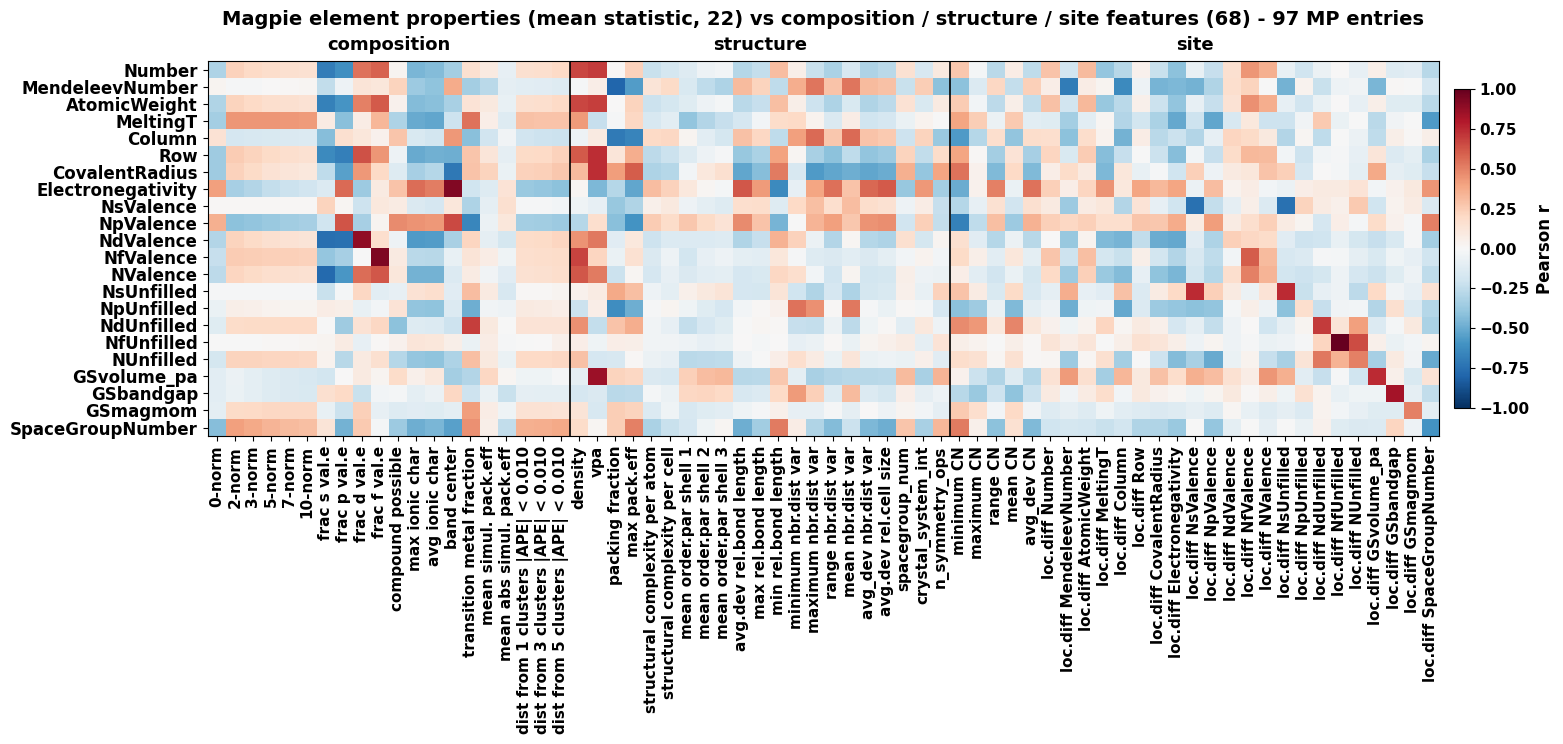

  composition   440 pairs,     36 with |r| > 0.5,   max |r| 0.934
  structure     462 pairs,     38 with |r| > 0.5,   max |r| 0.858
  site          594 pairs,     31 with |r| > 0.5,   max |r| 1.000


In [28]:
SHORT = {"mean local difference in ": "loc.diff ", " ordering parameter ": " order.par ",
         "mean absolute deviation in ": "avg.dev ", "relative ": "rel.",
         "CN_VoronoiNN": "CN", "neighbor distance variation": "nbr.dist var",
         "packing efficiency": "pack.eff", " valence electrons": " val.e"}


def short(label):
    for a, b in SHORT.items():
        label = label.replace(a, b)
    return label


def corr_rows(rows, method="pearson"):
    """rows = {row name: values} -> correlation against every column of FEAT."""
    return pd.DataFrame({k: FEAT.apply(lambda c: v.corr(c, method=method)
                                       if c.std() > 0 else np.nan)
                         for k, v in rows.items()}).T


def corr_map(M, title, figsize):
    """rows = Magpie properties, columns = features of FEAT. Figure text stays English."""
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(M.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels([short(c) for c in M.columns], rotation=90, fontsize=11)
    ax.set_yticks(range(M.shape[0]))
    ax.set_yticklabels(M.index, fontsize=12)
    lo = 0
    for name, block in BLOCKS.items():
        hi = lo + block.shape[1]
        if lo:
            ax.axvline(lo - 0.5, color="k", lw=1.2)
        ax.text((lo + hi - 1) / 2, -0.9, name, ha="center", va="bottom", fontsize=13)
        lo = hi
    ax.set_title(title, pad=26, fontsize=14)
    fig.colorbar(im, ax=ax, pad=0.01, shrink=0.85).set_label("Pearson r", fontsize=12)
    fig.tight_layout()
    return fig


R = corr_rows({p: PMAT[p] for p in PROPS})
corr_map(R, f"Magpie element properties ({STAT} statistic, {len(PROPS)}) vs "
            f"composition / structure / site features ({FEAT.shape[1]}) "
            f"- {len(FEAT)} MP entries", (17, 7.6))
plt.show()

for name, block in BLOCKS.items():
    sub = R[list(block.columns)]
    print(f"  {name:12s} {int(sub.notna().sum().sum()):4d} pairs,   "
          f"{int((sub.abs() > 0.5).sum().sum()):4d} with |r| > 0.5,   "
          f"max |r| {sub.abs().max().max():.3f}")

## References and citations

- **matminer** — <https://hackingmaterials.lbl.gov/matminer/> (LBNL Hacking Materials).
  The list of featurizers and the preset names follow this documentation.
- **matminer_examples** — `machine_learning-nb/voronoi-ward-prb-2017.ipynb` (LBNL).
  The Ward *et al.* recipe in Part 5 comes from there.
- **matminer-notes** (`codes/matminer-notes.ipynb`) — the shape and the voice of this
  notebook.
- **Materials Project** (CC BY 4.0) — every crystal structure in `data/cif/`, and
  the 100 `data/mp100_*` entries used in Part 6. The code that fetches them is
  `data/fetch_from_mp.py` and `data/fetch_02_sets.py`.

Original papers. This notebook runs more than forty featurizers, so they are not all listed
here; the source of each one can be read off with `citations()`, as shown in Part 2.

- L. Ward *et al.*, *Comput. Mater. Sci.* **152**, 60 (2018) — matminer
- S. P. Ong *et al.*, *Comput. Mater. Sci.* **68**, 314 (2013) — pymatgen
- L. Ward *et al.*, *npj Comput. Mater.* **2**, 16028 (2016) — the Magpie composition features
- L. Ward *et al.*, *Phys. Rev. B* **96**, 024104 (2017) — the Voronoi-based structure features
- N. E. R. Zimmermann & A. Jain, *RSC Adv.* **10**, 6063 (2020) — `CrystalNN` and the
  coordination-geometry order parameters